### Question:

I have a question regarding the nearest-neighbor results from Task 5.3.

For several words such as "sweden", "stockholm", and "london", the nearest neighbors do not seem very semantically related. In addition, most cosine similarity values are only around 0.2.

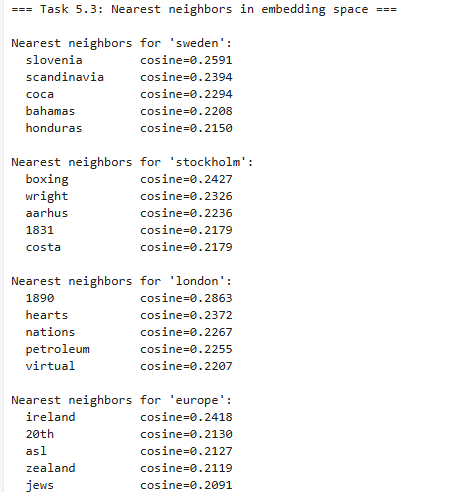

I was wondering whether this is expected behavior for this model and embedding space. 

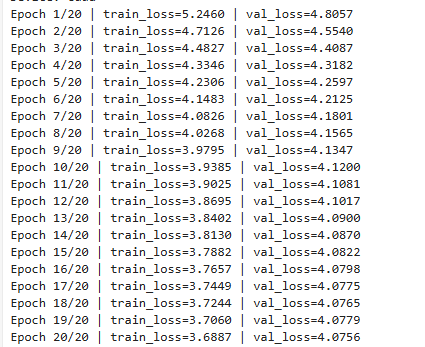

This is the loss values during training. Thank you!

In [1]:
import torch, nltk, pickle
from torch import nn
from collections import Counter
from transformers import BatchEncoding, PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput

from torch.utils.data import DataLoader
import numpy as np
import sys, time, os

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /cephyr/users/yingyi/Alvis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
current_path = os.getcwd()
train_path = os.path.join(current_path, "train.txt")
val_path = os.path.join(current_path, "val.txt")

### Part 1. Tokenization.

In [3]:
def lowercase_tokenizer(text):
    return [t.lower() for t in nltk.word_tokenize(text)]

def build_tokenizer(train_file, tokenize_fun=lowercase_tokenizer, max_voc_size=None, model_max_length=None,
                    pad_token='<PAD>', unk_token='<UNK>', bos_token='<BOS>', eos_token='<EOS>'):
    """ Build a tokenizer from the given file.

        Args:
             train_file:        The name of the file containing the training texts.
             tokenize_fun:      The function that maps a text to a list of string tokens.
             max_voc_size:      The maximally allowed size of the vocabulary.
             model_max_length:  Truncate texts longer than this length.
             pad_token:         The dummy string corresponding to padding.
             unk_token:         The dummy string corresponding to out-of-vocabulary tokens.
             bos_token:         The dummy string corresponding to the beginning of the text.
             eos_token:         The dummy string corresponding to the end the text.
    """

    # TODO: build the vocabulary, possibly truncating it to max_voc_size if that is specified.
    # Then return a tokenizer object (implemented below).
    counter = Counter()
    with open(train_file, 'r', encoding="utf-8") as f:
        for line in f:
            tokens = tokenize_fun(line)
            counter.update(tokens)

    special_tokens = [pad_token, unk_token, bos_token, eos_token]

    if max_voc_size is not None:
        most_common = counter.most_common(max_voc_size - len(special_tokens))
        common_tokens = [token for token, _ in most_common]
    else:
        common_tokens =  [token for token, _ in counter.most_common()]

    vocab = {token: i for i, token in enumerate(special_tokens + common_tokens)}

    return A1Tokenizer(
        vocab=vocab,
        tokenize_fun=tokenize_fun,
        model_max_length=model_max_length,
        pad_token=pad_token,
        unk_token=unk_token,
        bos_token=bos_token,
        eos_token=eos_token
    )


class A1Tokenizer:
    """A minimal implementation of a tokenizer similar to tokenizers in the HuggingFace library."""

    def __init__(self, vocab, tokenize_fun, model_max_length, pad_token='<PAD>', unk_token='<UNK>',
                 bos_token='<BOS>', eos_token='<EOS>'):
        # TODO: store all values you need in order to implement __call__ below.
        #self.pad_token_id = ...     # Compulsory attribute.
        #self.model_max_length = ... # Needed for truncation.
        self.vocab = vocab
        self.tokenize_fun = tokenize_fun
        self.model_max_length = model_max_length

        self.token2id = vocab                                       # str -> int
        self.id2token = {i: token for token, i in vocab.items()}   # int -> str

        self.pad_token = pad_token
        self.unk_token = unk_token
        self.bos_token = bos_token
        self.eos_token = eos_token

        self.pad_token_id = vocab[pad_token]  
        self.unk_token_id = vocab[unk_token]   
        self.bos_token_id = vocab[bos_token]
        self.eos_token_id = vocab[eos_token]

    def __call__(self, texts, truncation=False, padding=False, return_tensors=None):
        """Tokenize the given texts and return a BatchEncoding containing the integer-encoded tokens.
           
           Args:
             texts:           The texts to tokenize.
             truncation:      Whether the texts should be truncated to model_max_length.
             padding:         Whether the tokenized texts should be padded on the right side.
             return_tensors:  If None, then return lists; if 'pt', then return PyTorch tensors.

           Returns:
             A BatchEncoding where the field `input_ids` stores the integer-encoded texts.
        """
        if return_tensors and return_tensors != 'pt':
            raise ValueError('Should be pt')
        
        # TODO: Your work here is to split the texts into words and map them to integer values.
        # 
        # - If `truncation` is set to True, the length of the encoded sequences should be 
        #   at most self.model_max_length.
        # - If `padding` is set to True, then all the integer-encoded sequences should be of the
        #   same length. That is: the shorter sequences should be "padded" by adding dummy padding
        #   tokens on the right side.
        # - If `return_tensors` is undefined, then the returned `input_ids` should be a list of lists.
        #   Otherwise, if `return_tensors` is 'pt', then `input_ids` should be a PyTorch 2D tensor.
        if isinstance(texts, str):
            texts = [texts]

        encoded_texts = []

        for text in texts:
            tokens = self.tokenize_fun(text)
            ids = [self.token2id.get(tok, self.unk_token_id) for tok in tokens]

            if truncation:
                ids = ids[:self.model_max_length]

            encoded_texts.append(ids)

            attention_mask = None


        if padding:
            max_len = max(len(ids) for ids in encoded_texts)

            if truncation:
                max_len = min(max_len, self.model_max_length)

            padded_texts = []
            attention_mask = []

            for ids in encoded_texts:
                if truncation:
                    ids = ids[:max_len]
                
                padding_length = max_len - len(ids)
                padded_ids = ids + [self.pad_token_id] * padding_length
                mask = [1] * len(ids) + [0] * padding_length

                padded_texts.append(padded_ids)
                attention_mask.append(mask)
        
            encoded_texts = padded_texts

        else:
            attention_mask = [[1] * len(ids) for ids in encoded_texts]

        if return_tensors == 'pt':
            input_ids = torch.tensor(encoded_texts, dtype=torch.long)
            attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        else:
            input_ids = encoded_texts
        
        
        # TODO: Return a BatchEncoding where input_ids stores the result of the integer encoding.
        # Optionally, if you want to be 100% HuggingFace-compatible, you should also include an 
        # attention mask of the same shape as input_ids. In this mask, padding tokens correspond
        # to the the value 0 and real tokens to the value 1.
        return BatchEncoding({'input_ids': input_ids, 'attention_mask': attention_mask})

    def __len__(self):
        """Return the size of the vocabulary."""
        return len(self.vocab)
    
    def save(self, filename):
        """Save the tokenizer to the given file."""
        with open(filename, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def from_file(filename):
        """Load a tokenizer from the given file."""
        with open(filename, 'rb') as f:
            return pickle.load(f)


In [4]:
tokenizer = build_tokenizer("train.txt", max_voc_size=10000)
vocab = tokenizer.vocab
inv_vocab = tokenizer.id2token

print("Vocabulary size:", len(vocab))

print("\nSpecial tokens:")
for tok in [tokenizer.pad_token, tokenizer.unk_token, tokenizer.bos_token, tokenizer.eos_token]:
    print(f"{tok}: id =", vocab.get(tok))

Vocabulary size: 10000

Special tokens:
<PAD>: id = 0
<UNK>: id = 1
<BOS>: id = 2
<EOS>: id = 3


In [5]:
print("Frequent word checks:")
for w in ["the", "and"]:
    print(f"{w}: {'in vocab' if w in vocab else 'NOT in vocab'}")

print("\nRare word checks:")
for w in ["cuboidal", "epiglottis"]:
    print(f"{w}: {'in vocab' if w in vocab else 'NOT in vocab'}")

# Round-trip check
print("\nRound-trip check:")
test_word = "the" if "the" in vocab else list(vocab.keys())[10]
idx = vocab[test_word]
recovered = inv_vocab[idx]
print("test_word =", test_word)
print("mapped id =", idx)
print("mapped back =", recovered)
print("Round-trip OK:", test_word == recovered)

Frequent word checks:
the: in vocab
and: in vocab

Rare word checks:
cuboidal: NOT in vocab
epiglottis: NOT in vocab

Round-trip check:
test_word = the
mapped id = 4
mapped back = the
Round-trip OK: True


In [6]:
tokenizer = build_tokenizer(
    "train.txt",
    max_voc_size=10000,
    model_max_length=256
)
test_texts = ['This is a test.', 'Another test.']

out = tokenizer(
    test_texts,
    return_tensors='pt',
    padding=True,
    truncation=True
)

print(out)
print(out["input_ids"])
print(out["attention_mask"])

{'input_ids': tensor([[ 35,  14,  11, 965,   6],
        [153, 965,   6,   0,   0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 0, 0]])}
tensor([[ 35,  14,  11, 965,   6],
        [153, 965,   6,   0,   0]])
tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 0, 0]])


###  Part 2. Loading the text files and creating batches.

In [7]:
from datasets import load_dataset
from torch.utils.data import DataLoader

TRAIN_FILE = train_path
VAL_FILE = val_path

# Load dataset
dataset = load_dataset(
    "text",
    data_files={
        "train": TRAIN_FILE,
        "val": VAL_FILE
    }
)

# Remove empty lines
dataset = dataset.filter(lambda x: x["text"].strip() != "")

print("Train size:", len(dataset["train"]))
print("Val size:", len(dataset["val"]))

# Create dataloader over raw texts
dl_raw = DataLoader(dataset["train"], batch_size=4, shuffle=True)

print("\nRaw batch:")
for batch in dl_raw:
    print(batch)
    break

# Create dataloader with tokenization
def collate_fn(batch):
    texts = [item["text"] for item in batch]
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

dl_tok = DataLoader(dataset["train"], batch_size=4, shuffle=True, collate_fn=collate_fn)

print("\nTokenized batch:")
for batch in dl_tok:
    print(batch)
    print("input_ids shape:", batch["input_ids"].shape)
    print("attention_mask shape:", batch["attention_mask"].shape)
    break

Train size: 147059
Val size: 17874

Raw batch:
{'text': ['Exxon Valdez oil spill', 'Unicode and its parallel standard, the ISO/IEC 10646 Universal Character Set, together constitute a modern, unified character encoding.  Rather than mapping characters directly to octets (bytes), they separately define what characters are available, corresponding natural numbers (code points), how those numbers are encoded as a series of fixed-size natural numbers (code units), and finally how those units are encoded as a stream of octets.  The purpose of this decomposition is to establish a universal set of characters that can be encoded in a variety of ways.  To describe this model correctly requires more precise terms than "character set" and "character encoding."  The terms used in the modern model follow:', 'Amiga 500 Plus', 'The parliament, the Grand Council of Basel-Stadt (Grosser Rat), consists of 100 seats, with members (called in German: "Grossrat/Grossrätin") elected every 4 years.  The sessi

### Part 3. Defining the model.

In [20]:
class A1RNNModelConfig(PretrainedConfig):
    """Configuration object that stores hyperparameters that define the RNN-based language model."""
    def __init__(self, vocab_size=0, embedding_size=256, hidden_size=512, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size

class A1RNNModel(PreTrainedModel):
    """The neural network model that implements a RNN-based language model."""
    config_class = A1RNNModelConfig
    
    def __init__(self, config):
        super().__init__(config)
        self.embedding = torch.nn.Embedding(num_embeddings=config.vocab_size, embedding_dim=config.embedding_size)
        self.rnn = torch.nn.LSTM(input_size=config.embedding_size, hidden_size=config.hidden_size, batch_first=True)
        self.unembedding = torch.nn.Linear(in_features=config.hidden_size, out_features=cofig.vocab_size)

        # Note: -100 is the value HuggingFace conventionally uses to refer to tokens
        # where we do not want to compute the loss.
        self.loss_func = torch.nn.CrossEntropyLoss(ignore_index=-100)


    def forward(self, input_ids, labels=None):
        """The forward pass of the RNN-based language model.
        
           Args:
             - input_ids:  The input tensor (2D), consisting of a batch of integer-encoded texts.
             - labels:     The reference tensor (2D), consisting of a batch of integer-encoded texts.
           Returns:
             A CausalLMOutput containing
               - logits:   The output tensor (3D), consisting of logits for all token positions for all vocabulary items.
               - loss:     The loss computed on this batch.           

        logits.shape = [batch, seq_len, vocab_size]
        labels.shape = [batch, seq_len]    
        """
        embedded = self.embedding(input_ids)
        output, (h_n, c_n) = self.rnn(embedded) 
        logits = self.unembedding(output)
        loss = None
        if labels is not None:
            shift_labels = labels[:, 1:].contiguous()        # [B, T-1]
            shift_logits = logits[:, :-1, :].contiguous()    # [B, T-1, V]
            
            labels = shift_labels.view(-1)                    # 2-dimensional -> 1-dimensional
            logits = shift_logits.view(-1, shift_logits.shape[-1])  # 3-dimensional -> 2-dimensional
            loss = self.loss_func(logits, labels)

        return CausalLMOutput(logits=logits, loss=loss)

SyntaxError: invalid syntax (1065397840.py, line 22)

In [19]:
vocab_size = 10000
N = 8

config = A1RNNModelConfig(
    vocab_size=vocab_size,
    embedding_size=256,
    hidden_size=1024
)

model = A1RNNModel(config)
model.eval()

input_ids = torch.randint(0, vocab_size, (1, N))

with torch.no_grad():
    outputs = model(input_ids)

print("Input shape: ", input_ids.shape)
print("Expected logits shape: ", (1, N, vocab_size))
print("Actual logits shape:   ", outputs.logits.shape)


Input shape:  torch.Size([1, 8])
Expected logits shape:  (1, 8, 10000)
Actual logits shape:    torch.Size([1, 8, 10000])


### Part 4. Training the language model.

In [10]:
## Hint: the following TrainingArguments hyperparameters may be relevant for your implementation:
#
# - optim:            What optimizer to use. You can assume that this is set to 'adamw_torch',
#                     meaning that we use the PyTorch AdamW optimizer.
# - eval_strategy:    You can assume that this is set to 'epoch', meaning that the model should
#                     be evaluated on the validation set after each epoch
# - use_cpu:          Force the trainer to use the CPU; otherwise, CUDA or MPS should be used.
#                     (In your code, you can just use the provided method select_device.)
# - learning_rate:    The optimizer's learning rate.
# - num_train_epochs: The number of epochs to use in the training loop.
# - per_device_train_batch_size: 
#                     The batch size to use while training.
# - per_device_eval_batch_size:
#                     The batch size to use while evaluating.
# - output_dir:       The directory where the trained model will be saved.

class A1Trainer:
    """A minimal implementation similar to a Trainer from the HuggingFace library."""

    def __init__(self, model, args, train_dataset, eval_dataset, tokenizer):
        """Set up the trainer.
           
           Args:
             model:          The model to train.
             args:           The training parameters stored in a TrainingArguments object.
             train_dataset:  The dataset containing the training documents.
             eval_dataset:   The dataset containing the validation documents.
             eval_dataset:   The dataset containing the validation documents.
             tokenizer:      The tokenizer.
        """
        self.model = model
        self.args = args
        self.train_dataset = train_dataset
        self.eval_dataset = eval_dataset
        self.tokenizer = tokenizer

        assert(args.optim == 'adamw_torch')
        assert(args.eval_strategy == 'epoch')

    def select_device(self):
        """Return the device to use for training, depending on the training arguments and the available backends."""
        if self.args.use_cpu:
            return torch.device('cpu')
        if not self.args.no_cuda and torch.cuda.is_available():
            return torch.device('cuda')
        if torch.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')
            
    def train(self):
        """Train the model."""
        args = self.args

        device = self.select_device()
        print('Device:', device)
        self.model.to(device)
        
        loss_func = torch.nn.CrossEntropyLoss(ignore_index=self.tokenizer.pad_token_id)

        # TODO: Relevant arguments: at least args.learning_rate, but you can optionally also consider
        # other Adam-related hyperparameters here.
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=args.learning_rate)

        # TODO: Relevant arguments: args.per_device_train_batch_size, args.per_device_eval_batch_size
        train_loader = DataLoader(self.train_dataset, batch_size=args.per_device_train_batch_size, shuffle=True)
        val_loader = DataLoader(self.eval_dataset, batch_size=args.per_device_eval_batch_size, shuffle=False)
        
        # TODO: Your work here is to implement the training loop.
        #       
        # for each training epoch (use args.num_train_epochs here):
        #   for each batch B in the training set:
        #
        #       PREPROCESSING AND FORWARD PASS:
        #       input_ids = apply your tokenizer to B
        #       labels = input_ids with padding replaced by -100
	    #       put input_ids and labels onto the GPU (or whatever device you use)
        #       apply the model to input_ids and labels
        #       get the loss from the model output
        #
        #       BACKWARD PASS AND MODEL UPDATE:
        #       optimizer.zero_grad()
        #       loss.backward()
        #       optimizer.step()
        for epoch in range(args.num_train_epochs):
            # =========================
            # Training
            # =========================
            self.model.train()
            total_train_loss = 0.0

            for batch in train_loader:
                enc = self.tokenizer(
                    batch,
                    truncation=True,
                    padding=True,
                    return_tensors='pt'
                )

                input_ids = enc['input_ids'].to(device)

                labels = input_ids.clone()

                labels[labels == self.tokenizer.pad_token_id] = -100

                input_ids = input_ids.to(device)
                labels = labels.to(device)

                outputs = self.model(input_ids=input_ids, labels=labels)
                loss = outputs.loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_train_loss += loss.item()

            avg_train_loss = total_train_loss / len(train_loader)

            self.model.eval()
            total_val_loss = 0.0

            with torch.no_grad():
                for batch in val_loader:
                    enc = self.tokenizer(
                        batch,
                        truncation=True,
                        padding=True,
                        return_tensors='pt'
                    )

                    input_ids = enc['input_ids']
                    labels = input_ids.clone()
                    labels[labels == self.tokenizer.pad_token_id] = -100

                    input_ids = input_ids.to(device)
                    labels = labels.to(device)

                    outputs = self.model(input_ids=input_ids, labels=labels)
                    loss = outputs.loss

                    total_val_loss += loss.item()

            avg_val_loss = total_val_loss / len(val_loader)

            print(
                f"Epoch {epoch+1}/{args.num_train_epochs} | "
                f"train_loss={avg_train_loss:.4f} | "
                f"val_loss={avg_val_loss:.4f}"
            )

        print(f'Saving to {args.output_dir}.')
        os.makedirs(args.output_dir, exist_ok=True)
        self.model.save_pretrained(args.output_dir)
        self.tokenizer.save(os.path.join(args.output_dir, "tokenizer.pkl"))

In [15]:
tokenizer = build_tokenizer(train_path, max_voc_size=10000, model_max_length=256)

with open(train_path, 'r', encoding='utf-8') as f:
    train_dataset = [line.strip() for line in f if line.strip()]

with open(val_path, 'r', encoding='utf-8') as f:
    val_dataset = [line.strip() for line in f if line.strip()]

config = A1RNNModelConfig(
    vocab_size=len(tokenizer),
    embedding_size=256,
    hidden_size=512
)
model = A1RNNModel(config)

class SimpleArgs:
    optim = 'adamw_torch'
    eval_strategy = 'epoch'
    learning_rate = 1e-3
    num_train_epochs = 10
    per_device_train_batch_size = 64
    per_device_eval_batch_size = 64
    use_cpu = False  
    no_cuda = False
    output_dir = "./output_model"

args = SimpleArgs()

trainer = A1Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer
)

print("Starting training...")
trainer.train()
print("Training complete!")

device = trainer.select_device()
model.to(device)

Starting training...
Device: cuda
Epoch 1/20 | train_loss=5.2460 | val_loss=4.8057
Epoch 2/20 | train_loss=4.7126 | val_loss=4.5540
Epoch 3/20 | train_loss=4.4827 | val_loss=4.4087
Epoch 4/20 | train_loss=4.3346 | val_loss=4.3182
Epoch 5/20 | train_loss=4.2306 | val_loss=4.2597
Epoch 6/20 | train_loss=4.1483 | val_loss=4.2125
Epoch 7/20 | train_loss=4.0826 | val_loss=4.1801
Epoch 8/20 | train_loss=4.0268 | val_loss=4.1565
Epoch 9/20 | train_loss=3.9795 | val_loss=4.1347
Epoch 10/20 | train_loss=3.9385 | val_loss=4.1200
Epoch 11/20 | train_loss=3.9025 | val_loss=4.1081
Epoch 12/20 | train_loss=3.8695 | val_loss=4.1017
Epoch 13/20 | train_loss=3.8402 | val_loss=4.0900
Epoch 14/20 | train_loss=3.8130 | val_loss=4.0870
Epoch 15/20 | train_loss=3.7882 | val_loss=4.0822
Epoch 16/20 | train_loss=3.7657 | val_loss=4.0798
Epoch 17/20 | train_loss=3.7449 | val_loss=4.0775
Epoch 18/20 | train_loss=3.7244 | val_loss=4.0765
Epoch 19/20 | train_loss=3.7060 | val_loss=4.0779
Epoch 20/20 | train_loss=

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


A1RNNModel(
  (embedding): Embedding(10000, 256)
  (rnn): LSTM(256, 512, batch_first=True)
  (unembedding): Linear(in_features=512, out_features=10000, bias=True)
  (loss_func): CrossEntropyLoss()
)

In [16]:
def predict_next_word(model, tokenizer, text, device, top_k=5):
    model.eval()

    enc = tokenizer(
        text,
        truncation=True,
        padding=False,
        return_tensors='pt'
    )

    input_ids = enc['input_ids'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids)
        logits = outputs.logits   # [1, seq_len, vocab_size]

    # Use the logits from the last token position
    last_logits = logits[0, -1, :]
    topk = torch.topk(last_logits, k=top_k)

    results = []
    for idx, score in zip(topk.indices, topk.values):
        token_id = idx.item()
        token_str = tokenizer.id2token[token_id]
        results.append((token_str, score.item()))

    return results


def compute_perplexity(model, tokenizer, dataset, batch_size, device):
    model.eval()
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            enc = tokenizer(
                batch,
                truncation=True,
                padding=True,
                return_tensors='pt'
            )

            input_ids = enc['input_ids'].to(device)
            labels = input_ids.clone()
            labels[labels == tokenizer.pad_token_id] = -100

            outputs = model(input_ids=input_ids, labels=labels)
            loss = outputs.loss

            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return perplexity


def nearest_neighbors(emb, voc, inv_voc, word, n_neighbors=5):
    if word not in voc:
        return []

    # Look up the embedding for the test word.
    test_emb = emb.weight[voc[word]]   # [embedding_dim]

    # We'll use a cosine similarity function to find the most similar words.
    sim_func = nn.CosineSimilarity(dim=1)
    cosine_scores = sim_func(test_emb.unsqueeze(0), emb.weight)

    # Find the positions of the highest cosine values.
    near_nbr = cosine_scores.topk(n_neighbors + 1)
    topk_cos = near_nbr.values[1:]
    topk_indices = near_nbr.indices[1:]

    # Finally, map word indices back to strings, and put the result in a list.
    return [(inv_voc[ix.item()], cos.item()) for ix, cos in zip(topk_indices, topk_cos)]


def plot_embeddings_pca(emb, voc, words, save_path="embeddings_pca.png"):
    import matplotlib.pyplot as plt
    from sklearn.decomposition import TruncatedSVD

    valid_words = [w for w in words if w in voc]
    if len(valid_words) < 2:
        print("Not enough words found in vocabulary for PCA plot.")
        return

    vectors = np.vstack([
        emb.weight[voc[w]].detach().cpu().numpy()
        for w in valid_words
    ])

    vectors = vectors - vectors.mean(axis=0)
    twodim = TruncatedSVD(n_components=2).fit_transform(vectors)

    plt.figure(figsize=(5, 5))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')

    for word, (x, y) in zip(valid_words, twodim):
        plt.text(x + 0.02, y, word)

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"PCA plot saved to {save_path}")

In [17]:


print("\n=== Task 5.1: Next-word prediction ===")
example_text = "She lives in San"
predictions = predict_next_word(model, tokenizer, example_text, device, top_k=5)

print(f"Input text: {example_text}")
print("Top-5 next-word predictions:")
for word, score in predictions:
    print(f"  {word:15s} score={score:.4f}")

print("\n=== Task 5.2: Perplexity on validation set ===")
ppl = compute_perplexity(
    model=model,
    tokenizer=tokenizer,
    dataset=val_dataset,
    batch_size=args.per_device_eval_batch_size,
    device=device
)
print(f"Validation perplexity: {ppl:.4f}")

print("\n=== Task 5.3: Nearest neighbors in embedding space ===")
test_words = ["sweden", "stockholm", "london", "europe"]
for word in test_words:
    neighbors = nearest_neighbors(
        model.embedding,
        tokenizer.token2id,
        tokenizer.id2token,
        word,
        n_neighbors=5
    )
    print(f"\nNearest neighbors for '{word}':")
    if not neighbors:
        print("  Word not found in vocabulary.")
    else:
        for neighbor, sim in neighbors:
            print(f"  {neighbor:15s} cosine={sim:.4f}")

# Optional PCA plot
plot_words = ['sweden', 'denmark', 'europe', 'africa', 'london', 'stockholm', 'large', 'small', 'great', 'black', '3', '7', '10', 'seven', 'three', 'ten', '1984', '2005', '2010']
plot_embeddings_pca(model.embedding, tokenizer.token2id, plot_words, save_path="embeddings_pca.png")



=== Task 5.1: Next-word prediction ===
Input text: She lives in San
Top-5 next-word predictions:
  <UNK>           score=7.7286
  diego           score=6.2274
  francisco       score=6.0119
  juan            score=4.7285
  fernando        score=4.6727

=== Task 5.2: Perplexity on validation set ===
Validation perplexity: 58.8886

=== Task 5.3: Nearest neighbors in embedding space ===

Nearest neighbors for 'sweden':
  slovenia        cosine=0.2591
  scandinavia     cosine=0.2394
  coca            cosine=0.2294
  bahamas         cosine=0.2208
  honduras        cosine=0.2150

Nearest neighbors for 'stockholm':
  boxing          cosine=0.2427
  wright          cosine=0.2326
  aarhus          cosine=0.2236
  1831            cosine=0.2179
  costa           cosine=0.2179

Nearest neighbors for 'london':
  1890            cosine=0.2863
  hearts          cosine=0.2372
  nations         cosine=0.2267
  petroleum       cosine=0.2255
  virtual         cosine=0.2207

Nearest neighbors for 'europe